# **KD Tree KNN** 
## **Project:**
- Location-Based Food Delivery Optimization 
## **Problem Statement:** 
- Identify nearest delivery partners using spatial coordinates.

In [1]:
# Step No 1 : Importing the required libraries 

# Import Numerical Library 
import numpy as np 

# Import Data Manipulation Library
import pandas as pd 

# Import Data Visualization Libraries
import matplotlib.pyplot as plt 

# Import Advanced Data Visualization Library 
import seaborn as sns 

# Import Machine Learning Library 
# Import Train Test Split Function 
from sklearn.model_selection import train_test_split

# Import Standard Scaler Function
from sklearn.preprocessing import StandardScaler

# Import KNN Classifier 
from sklearn.neighbors import KNeighborsClassifier

# Importing the Metrics for Evaluation
from sklearn.metrics import classification_report , accuracy_score , confusion_matrix


In [2]:
# Step No 2 : Loading the Dataset 
df = pd.read_csv("KDTree_Food_Delivery_Dataset.csv")

In [3]:
# Step No 3 : Data Preprocessing and analysis

# Display the first 5 rows of the dataset 
print(df.head())

# Display the shape of the dataset 
print(df.shape)

# Display the Statistical Summary of the dataset 
print(df.describe())

# Display the Information about the dataset 
print(df.info())

   OrderID  CustomerID  CustomerLatitude  CustomerLongitude  PartnerID  \
0        1       25795         19.918359          75.349665       1860   
1        2       94478         19.973964          75.258193       8849   
2        3       97313         19.879556          75.296354       9792   
3        4       87189         19.757202          75.410571       4843   
4        5       99812         19.812410          75.407184       7863   

   PartnerLatitude  PartnerLongitude  RestaurantID  RestaurantLatitude  \
0        19.883961         75.315264           770           19.847652   
1        19.933025         75.270032           975           19.955158   
2        19.831153         75.269443           815           19.838120   
3        19.752177         75.400086           809           19.825467   
4        19.798085         75.385277           736           19.819241   

   RestaurantLongitude  DistanceKM TrafficLevel WeatherCondition  \
0            75.408253        5.40        

In [4]:
# Step No 4 : Data Cleaning 

# Check for missing values in the dataset 
print(df.isnull().sum())

# Check for duplicate values in the dataset 
print(df.duplicated().sum())

# Remove duplicate values from the dataset 
df = df.drop_duplicates()

OrderID                0
CustomerID             0
CustomerLatitude       0
CustomerLongitude      0
PartnerID              0
PartnerLatitude        0
PartnerLongitude       0
RestaurantID           0
RestaurantLatitude     0
RestaurantLongitude    0
DistanceKM             0
TrafficLevel           0
WeatherCondition       0
PartnerRating          0
PartnerAvailability    0
OrderValue             0
DeliveryTimeMinutes    0
dtype: int64
0


In [5]:
# Step No 5 : Encode Target Variable 
# Convert Available = 1 
# Convert Busy = 0
df["PartnerAvailability"] = df["PartnerAvailability"].map({
    "Available": 1,
    "Busy": 0
})

In [6]:
# Step No 6 : Feature and Target Variable Selection 

# Define Input Features 
X = df[[
    "CustomerLatitude",
    "CustomerLongitude",
    "PartnerLatitude",
    "PartnerLongitude",
    "DistanceKM",
    "PartnerRating",
    "OrderValue"
]]

# Define Target Variable 
y = df["PartnerAvailability"]

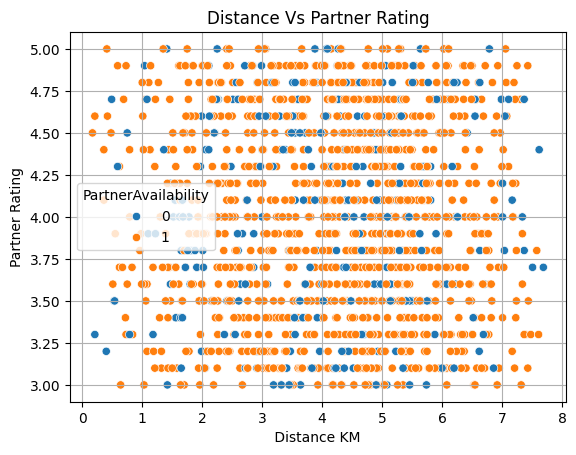

In [7]:
# Step No 7 : Visualization of the dataset 

# Create Scatter Plot 
sns.scatterplot(
    x = "DistanceKM",
    y = "PartnerRating",
    hue = "PartnerAvailability",
    data = df
)

# Set Plot Title 
plt.title("Distance Vs Partner Rating")

# Set X-axis Label
plt.xlabel(" Distance KM ")

# Set Y-axis Label
plt.ylabel("Partner Rating")

# Enable Grid 
plt.grid()

# Save Figure 
plt.savefig("images/Distance_Vs_Partner_Rating(KDTree KNN).png")

# Show Plot 
plt.show()

In [8]:
# Step No 8 : Train Test Split
X_train , X_test , y_train , y_test  = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)

In [9]:
# Step No 9 : Feature Scaling 
# Create Scaler Object 
scaler = StandardScaler()

# Scale Training Data 
X_train = scaler.fit_transform(X_train)

# Scale Testing Data
X_test = scaler.fit_transform(X_test)

In [10]:
# Step No 10 : Create KD Tree KNN Model
model = KNeighborsClassifier(
    n_neighbors= 5 , 
    algorithm= "kd_tree"
)

# Algorithm = "kd_tree"
# KD Tree used for fast nearest neighbor search 


In [11]:
# Step No 11 : Train the Model 
model.fit(X_train , y_train)

KNeighborsClassifier(algorithm='kd_tree')

In [12]:
# Step No 12 : Predict the Test Set Results
y_pred = model.predict(X_test)

# Display the predicted values 
print("Predicted Values : ")
print(y_pred)

Predicted Values : 
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1]


In [13]:
# Step No 13 : Evaluate the Model 

# Calculate Accuaracy Score 
print("Accuracy Score : ")
print(accuracy_score(y_test , y_pred))

# Calcualate Classification Report 
print("Classification Report : ")
print(classification_report(y_test , y_pred))

#Calculate Confusion Matrix 
print("Confusion Matrix : ")
print(confusion_matrix(y_test , y_pred))

Accuracy Score : 
0.8066666666666666
Classification Report : 
              precision    recall  f1-score   support

           0       0.30      0.06      0.09        54
           1       0.82      0.97      0.89       246

    accuracy                           0.81       300
   macro avg       0.56      0.51      0.49       300
weighted avg       0.73      0.81      0.75       300

Confusion Matrix : 
[[  3  51]
 [  7 239]]


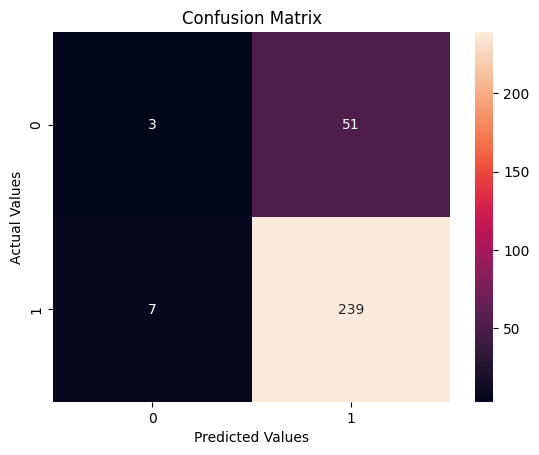

In [14]:
# Step No 14 : Plot Confusion Matrix 
sns.heatmap(
    confusion_matrix(y_test , y_pred),
    annot = True,
    fmt = "d"
)

# Set Plot Title 
plt.title("Confusion Matrix")

# Set X-axis Label 
plt.xlabel("Predicted Values")

# Set y-axis Label
plt.ylabel("Actual Values")

# Save Figure 
plt.savefig("images/Confusion Matrix(KDTree KNN).png")

# Show Plot 
plt.show()

In [15]:
# Step No 15 : User Input for Prediction 
customer_longitude = float(input("Enter Customer Latitude : "))

customer_latitude = float(input("Enter Customer Latitude : ")) 

partner_latitude = float(input("Enter Partner Latitude : "))

partner_longitude = float(input("Enter Partner Longitude : "))

distance = float(input("Enter Distance KM : "))

partner_rating = float(input("Enter Partner Rating : "))

order_value = float(input("Enter Order Value : "))

In [18]:
# Step No 16 : Create User DataFrame 

user_data = pd.DataFrame({
    "CustomerLatitude": [customer_latitude] , 
    
    "CustomerLongitude": [customer_longitude],
    
    "PartnerLatitude": [partner_latitude],
    
    "PartnerLongitude": [partner_longitude],
    
    "DistanceKM": [distance],
    
    "PartnerRating": [partner_rating],
    
    "OrderValue": [order_value]
    
})

In [19]:
# Step No 17 : Scale User Data 
user_data = scaler.transform(user_data)

In [20]:
# Step No 18 : Predict User Data 
result = model.predict(user_data)

In [21]:
# Final Output 
if result[0] == 1 :
    print("Nearest Delivery Partner Available .")
else: 
    print("Nearest Delivery Partner Busy.")

Nearest Delivery Partner Available .
